This is a simulation based on the Fraunhofer diffraction theory.

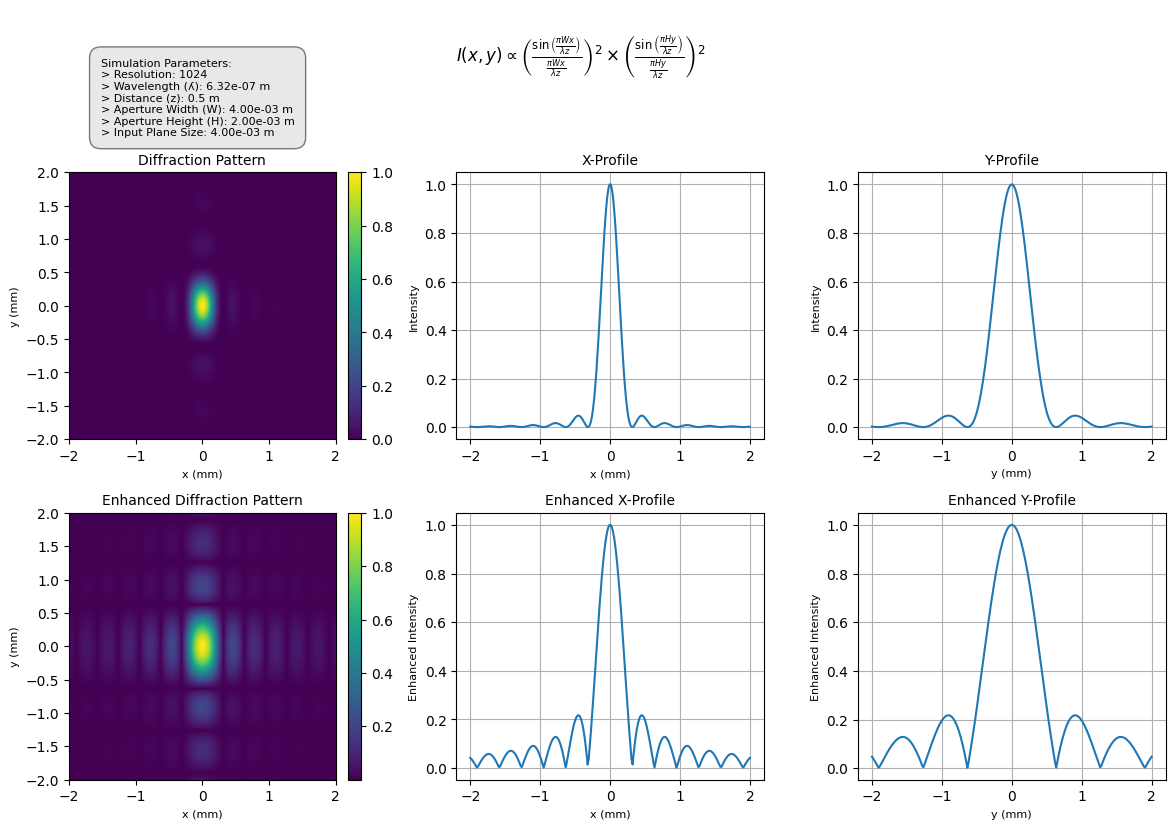

In [2]:
# %pip install numpy
# %pip install matplotlib
# %pip install latex2sympy2
# %pip install sympy

import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
from matplotlib.offsetbox import AnchoredText
from sympy import latex # type: ignore

sim_resolution = 1024
wavelength = 632e-9
z = 0.5
W = 4e-3
H = 2e-3
input_plane_size = 4e-3

# Create spatial viewing grid
x = np.linspace(-input_plane_size / 2, input_plane_size / 2, sim_resolution)
y = np.linspace(-input_plane_size / 2, input_plane_size / 2, sim_resolution)
X, Y = np.meshgrid(x, y)

# Fraunhofer diffraction calculation (pattern dimensions)
i_x = (np.pi * W * X) / (wavelength * z)
i_y = (np.pi * H * Y) / (wavelength * z)

# Avoid division by zero
i_x[i_x == 0] = 1e-10
i_y[i_y == 0] = 1e-10

# Fraunhofer diffraction equation (intensity)
intensity = (np.sin(i_x)/i_x)**2 * (np.sin(i_y)/i_y)**2

# Normalize intensity for better visualization
intensity /= np.max(intensity)

# Extract central profiles
central_region = slice(sim_resolution // 2 - sim_resolution // 8, sim_resolution // 2 + sim_resolution // 8)
spatial_coords_central = np.linspace(-input_plane_size / 2 * 1e3, input_plane_size / 2 * 1e3, central_region.stop - central_region.start)

x_profile = intensity[sim_resolution // 2, central_region]
y_profile = intensity[central_region, sim_resolution // 2]

# Visualization
plt.figure(figsize=(12, 8))

# REGULAR
plt.subplot(2, 3, 1)
plt.imshow(intensity[central_region, central_region], extent=[spatial_coords_central[0], spatial_coords_central[-1], spatial_coords_central[0], spatial_coords_central[-1]], cmap='viridis', origin='lower')
plt.title("Diffraction Pattern", fontsize=10)
plt.xlabel("x (mm)", fontsize=8)
plt.ylabel("y (mm)", fontsize=8)
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(2, 3, 2)
plt.plot(spatial_coords_central, x_profile)
plt.title("X-Profile", fontsize=10)
plt.xlabel("x (mm)", fontsize=8)
plt.ylabel("Intensity", fontsize=8)
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(spatial_coords_central, y_profile)
plt.title("Y-Profile", fontsize=10)
plt.xlabel("y (mm)", fontsize=8)
plt.ylabel("Intensity", fontsize=8)
plt.grid(True)

# ENHANCED
enhanced_intensity = np.sqrt(intensity) # Apply square root to enhance lower intensities
enhanced_intensity /= np.max(enhanced_intensity) # re-normalize

enhanced_x_profile = np.sqrt(x_profile)
enhanced_x_profile /= np.max(enhanced_x_profile)

enhanced_y_profile = np.sqrt(y_profile)
enhanced_y_profile /= np.max(enhanced_y_profile)

plt.subplot(2, 3, 4)
plt.imshow(enhanced_intensity[central_region, central_region], extent=[spatial_coords_central[0], spatial_coords_central[-1], spatial_coords_central[0], spatial_coords_central[-1]], cmap='viridis', origin='lower')
plt.title("Enhanced Diffraction Pattern", fontsize=10)
plt.xlabel("x (mm)", fontsize=8)
plt.ylabel("y (mm)", fontsize=8)
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(2, 3, 5)
plt.plot(spatial_coords_central, enhanced_x_profile)
plt.title("Enhanced X-Profile", fontsize=10)
plt.xlabel("x (mm)", fontsize=8)
plt.ylabel("Enhanced Intensity", fontsize=8)
plt.grid(True)

plt.subplot(2, 3, 6)
plt.plot(spatial_coords_central, enhanced_y_profile)
plt.title("Enhanced Y-Profile", fontsize=10)
plt.xlabel("y (mm)", fontsize=8)
plt.ylabel("Enhanced Intensity", fontsize=8)
plt.grid(True)

equation = r"""
$I(x,y) \propto \left( \frac{\sin{\left( \frac{\pi Wx}{\lambda z} \right)}}{\frac{\pi Wx}{\lambda z}} \right)^2 \times \left( \frac{\sin{\left( \frac{\pi Hy}{\lambda z} \right)}}{\frac{\pi Hy}{\lambda z}} \right)^2$
"""
plt.gcf().text(0.5, 0.95, equation, fontsize=12, ha='center')

params_text = (
    f"Simulation Parameters:\n"
    f"> Resolution: {sim_resolution}\n"
    f"> Wavelength (ʎ): {wavelength:.2e} m\n"
    f"> Distance (z): {z} m\n"
    f"> Aperture Width (W): {W:.2e} m\n"
    f"> Aperture Height (H): {H:.2e} m\n"
    f"> Input Plane Size: {input_plane_size:.2e} m"
)

props = dict(boxstyle='round', facecolor='lightgray', alpha=0.5, pad=1)
plt.gcf().text(0.1, 1, params_text, fontsize=8, verticalalignment='top', horizontalalignment='left', bbox=props)

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()
